In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv"
df = pd.read_csv(url)

In [3]:
print("1. First 5 Records")
print(df.head())
print("______________________________________________________________________________")
print("\n2. Dataset Shape")
print(df.shape)
print("______________________________________________________________________________")
print("\n3. Columns Names")
print(df.columns)
print("______________________________________________________________________________")
print("\n4. Dataset Information")
print(df.info())
print("______________________________________________________________________________")
print("\n5. Summary Satistics")
print(df.describe())

1. First 5 Records
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500 

In [4]:
print("1. Missing Values")
print(df.isnull().sum())

df["Age"].fillna(df["Age"].median(), inplace=True)

1. Missing Values
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


/tmp/ipykernel_2598/2866837939.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)


In [5]:
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)   # mode is used because 'Embarked' is in character datatype.

df.drop("Cabin", axis=1, inplace=True)

print("\n1. Missing Values After Cleaning")
print(df.isnull().sum())


1. Missing Values After Cleaning
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_2598/504417291.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)   # mode is used because 'Embarked' is in character datatype.



Survival Count
Survived
0    549
1    342
Name: count, dtype: int64


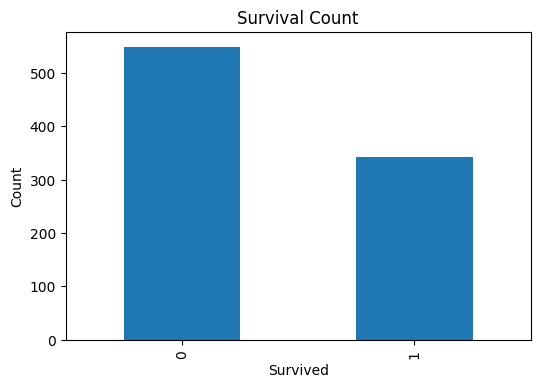

In [6]:
survival = df["Survived"].value_counts()
print("\nSurvival Count")
print(survival)
plt.figure(figsize=(6,4))
survival.plot(kind='bar')
plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()


Gender Analysis
Sex
male      577
female    314
Name: count, dtype: int64


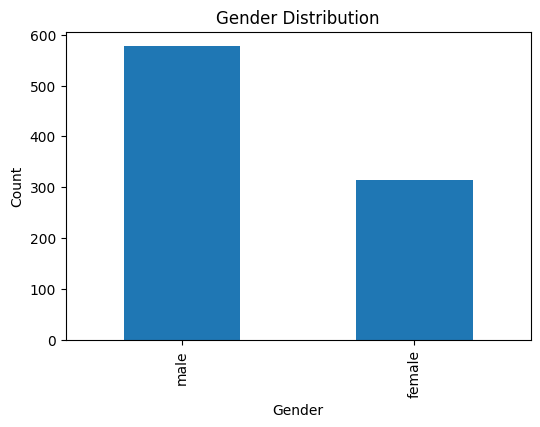

In [7]:
# Gender Analysis
gender = df["Sex"].value_counts()
print("\nGender Analysis")
print(gender)
plt.figure(figsize=(6,4))
gender.plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


Gender Analysis
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


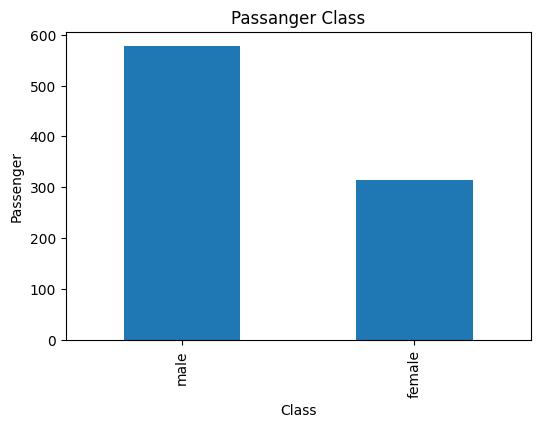

In [8]:
# Passanger Class Distribution
pclass = df["Pclass"].value_counts()
print("\nGender Analysis")
print(pclass)
plt.figure(figsize=(6,4))
gender.plot(kind='bar')
plt.title("Passanger Class")
plt.xlabel("Class")
plt.ylabel("Passenger")
plt.show()

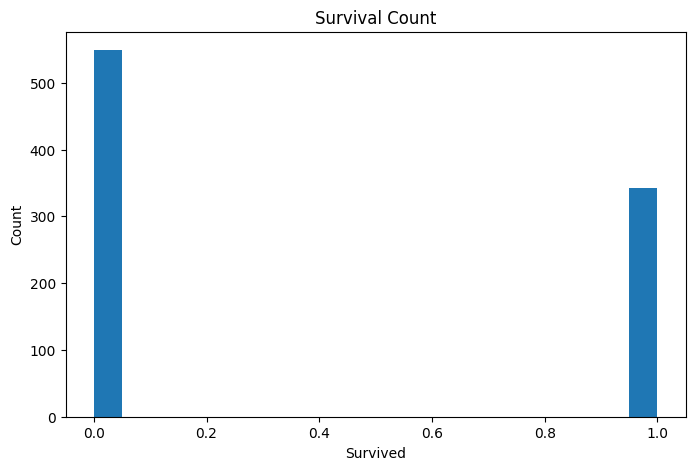

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df["Survived"], bins=20)
plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

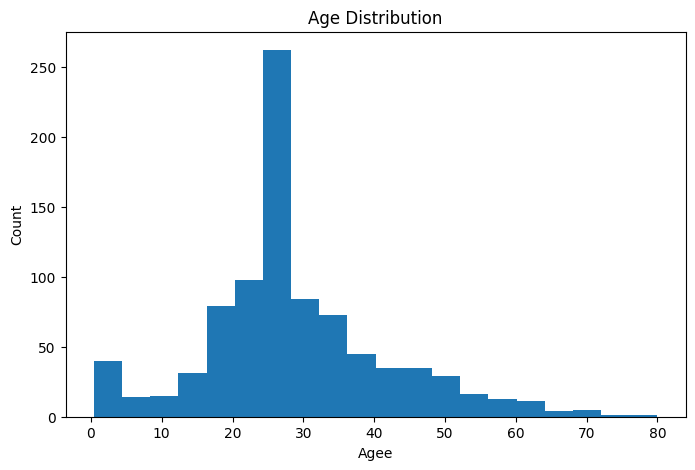

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Agee")
plt.ylabel("Count")
plt.show()

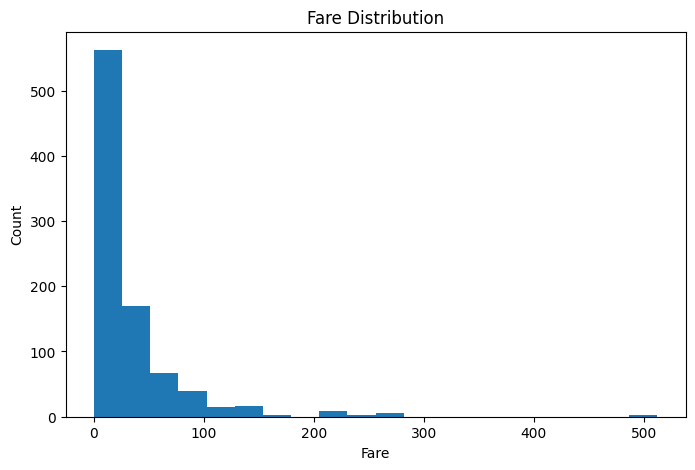

In [11]:
plt.figure(figsize=(8,5))
plt.hist(df["Fare"], bins=20)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()


Correlation Matrix
             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.034212 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.064910 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.339898  0.083081  0.018443   
Age             0.034212 -0.064910 -0.339898  1.000000 -0.233296 -0.172482   
SibSp          -0.057527 -0.035322  0.083081 -0.233296  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.172482  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096688  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096688  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


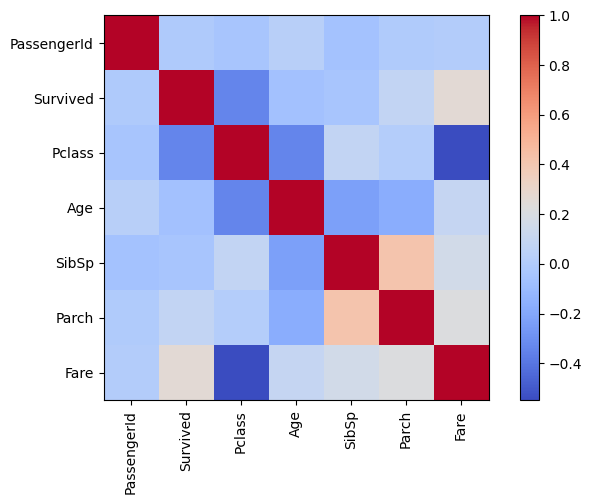

In [12]:
numeric_df = df.select_dtypes(include=np.number)
correlation = numeric_df.corr()
print("\nCorrelation Matrix")
print(correlation)

plt.figure(figsize=(8,5))
plt.imshow(correlation, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.show()

In [13]:
# Group Analysis
print("1. Average Fare by Passenger Class")
print(df.groupby("Pclass")["Fare"].mean())
print("\n___________________________________________________________________________\n")
print("\n2. Average Age by Gender")
print(df.groupby("Sex")["Age"].mean())
print("\n___________________________________________________________________________\n")
print("\n3. Survival Rate by Gender")
print(df.groupby("Sex")["Survived"].mean())
print("\n___________________________________________________________________________\n")
print("\n4. Survival Rate by Passenger Class")
print(df.groupby("Pclass")["Survived"].mean())

1. Average Fare by Passenger Class
Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

___________________________________________________________________________


2. Average Age by Gender
Sex
female    27.929936
male      30.140676
Name: Age, dtype: float64

___________________________________________________________________________


3. Survival Rate by Gender
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

___________________________________________________________________________


4. Survival Rate by Passenger Class
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [14]:
print("1. Top 10 Highest Fare Passengers")
print(df.nlargest(10, "Fare")[["Name", "Fare", "Pclass"]])
print("\n___________________________________________________________________________\n")
df.to_csv("cleaned_titanic.csv", index=False)
print("\n2. Cleaned dataset saved successfully.")

1. Top 10 Highest Fare Passengers
                                      Name      Fare  Pclass
258                       Ward, Miss. Anna  512.3292       1
679     Cardeza, Mr. Thomas Drake Martinez  512.3292       1
737                 Lesurer, Mr. Gustave J  512.3292       1
27          Fortune, Mr. Charles Alexander  263.0000       1
88              Fortune, Miss. Mabel Helen  263.0000       1
341         Fortune, Miss. Alice Elizabeth  263.0000       1
438                      Fortune, Mr. Mark  263.0000       1
311             Ryerson, Miss. Emily Borie  262.3750       1
742  Ryerson, Miss. Susan Parker "Suzette"  262.3750       1
118               Baxter, Mr. Quigg Edmond  247.5208       1

___________________________________________________________________________


2. Cleaned dataset saved successfully.
